In [1]:
### Plotting the analytic solution G(t, U, iw_n) and G(t(U), U, iw_n)
import numpy as np
import matplotlib.pyplot as plt
import itertools as it
import pickle
from pydlr import dlr
import cvxpy as cp
import WCE as wce
import SCE as sce

In [2]:
beta = 80.0
Ntau = 401
Ns = 8
Nw = 200
Mat_fre = (2*np.linspace(0, Nw-1, Nw)+1)*np.pi/beta
wn = np.append(-np.flip(Mat_fre),Mat_fre)   # w_n = (2n+1)*pi/beta

In [3]:
t_values_wce = np.linspace(0,5,11)
t_values_sce = np.linspace(0,0.5,11)
Gij_iwn_sce = np.zeros((len(t_values_sce), wn.size, Ns**2, Ns**2), dtype ='complex')
Gij_iwn_wce = np.zeros((len(t_values_wce), wn.size, Ns**2, Ns**2), dtype ='complex')
Gij_iwn_hf = np.zeros((len(t_values_wce), wn.size, Ns**2, Ns**2), dtype ='complex')
for t in range(t_values_sce.size):
    Gij_iwn_sce[t]= sce.G_sce(2, Ns, Ns, 1.0, t_values_sce[t], wn, beta)
for t in range(t_values_wce.size):
    print(t)
    Gij_iwn_hf[t], _ = wce.HF_G0(Ns, Ns, wn, t_values_wce[t])
    Gij_iwn_wce[t], _ = wce.G_wce(2, Ns, Ns, 1.0, t_values_wce[t], wn, beta)

0
1
2
3
4
5
6
7
8
9
10


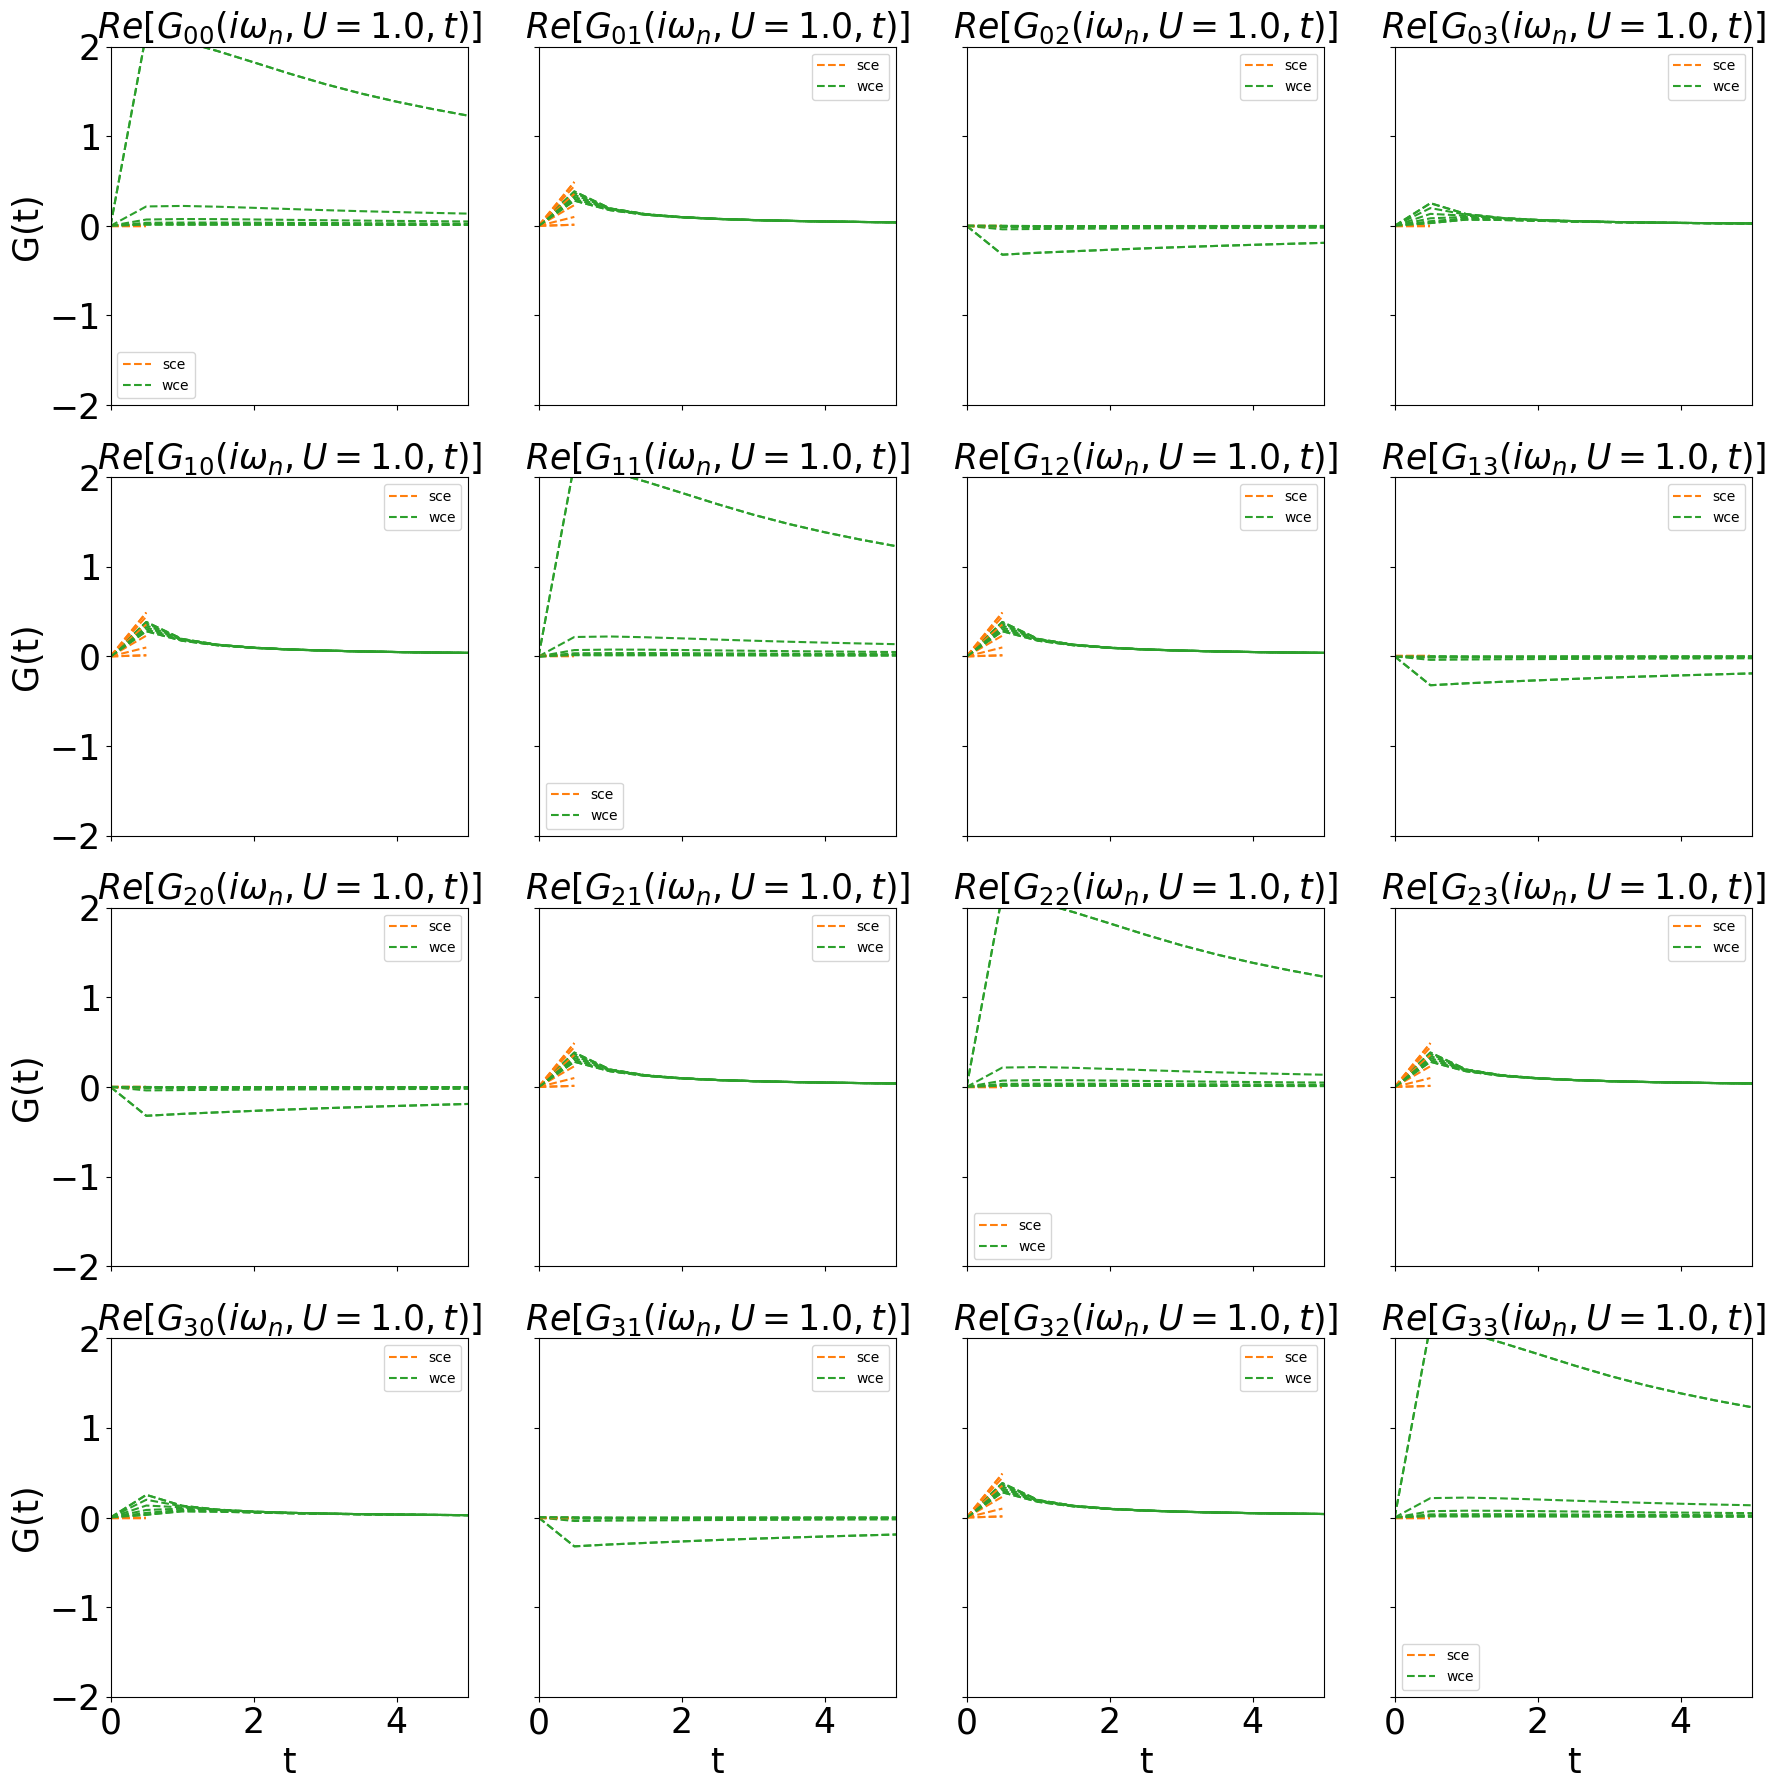

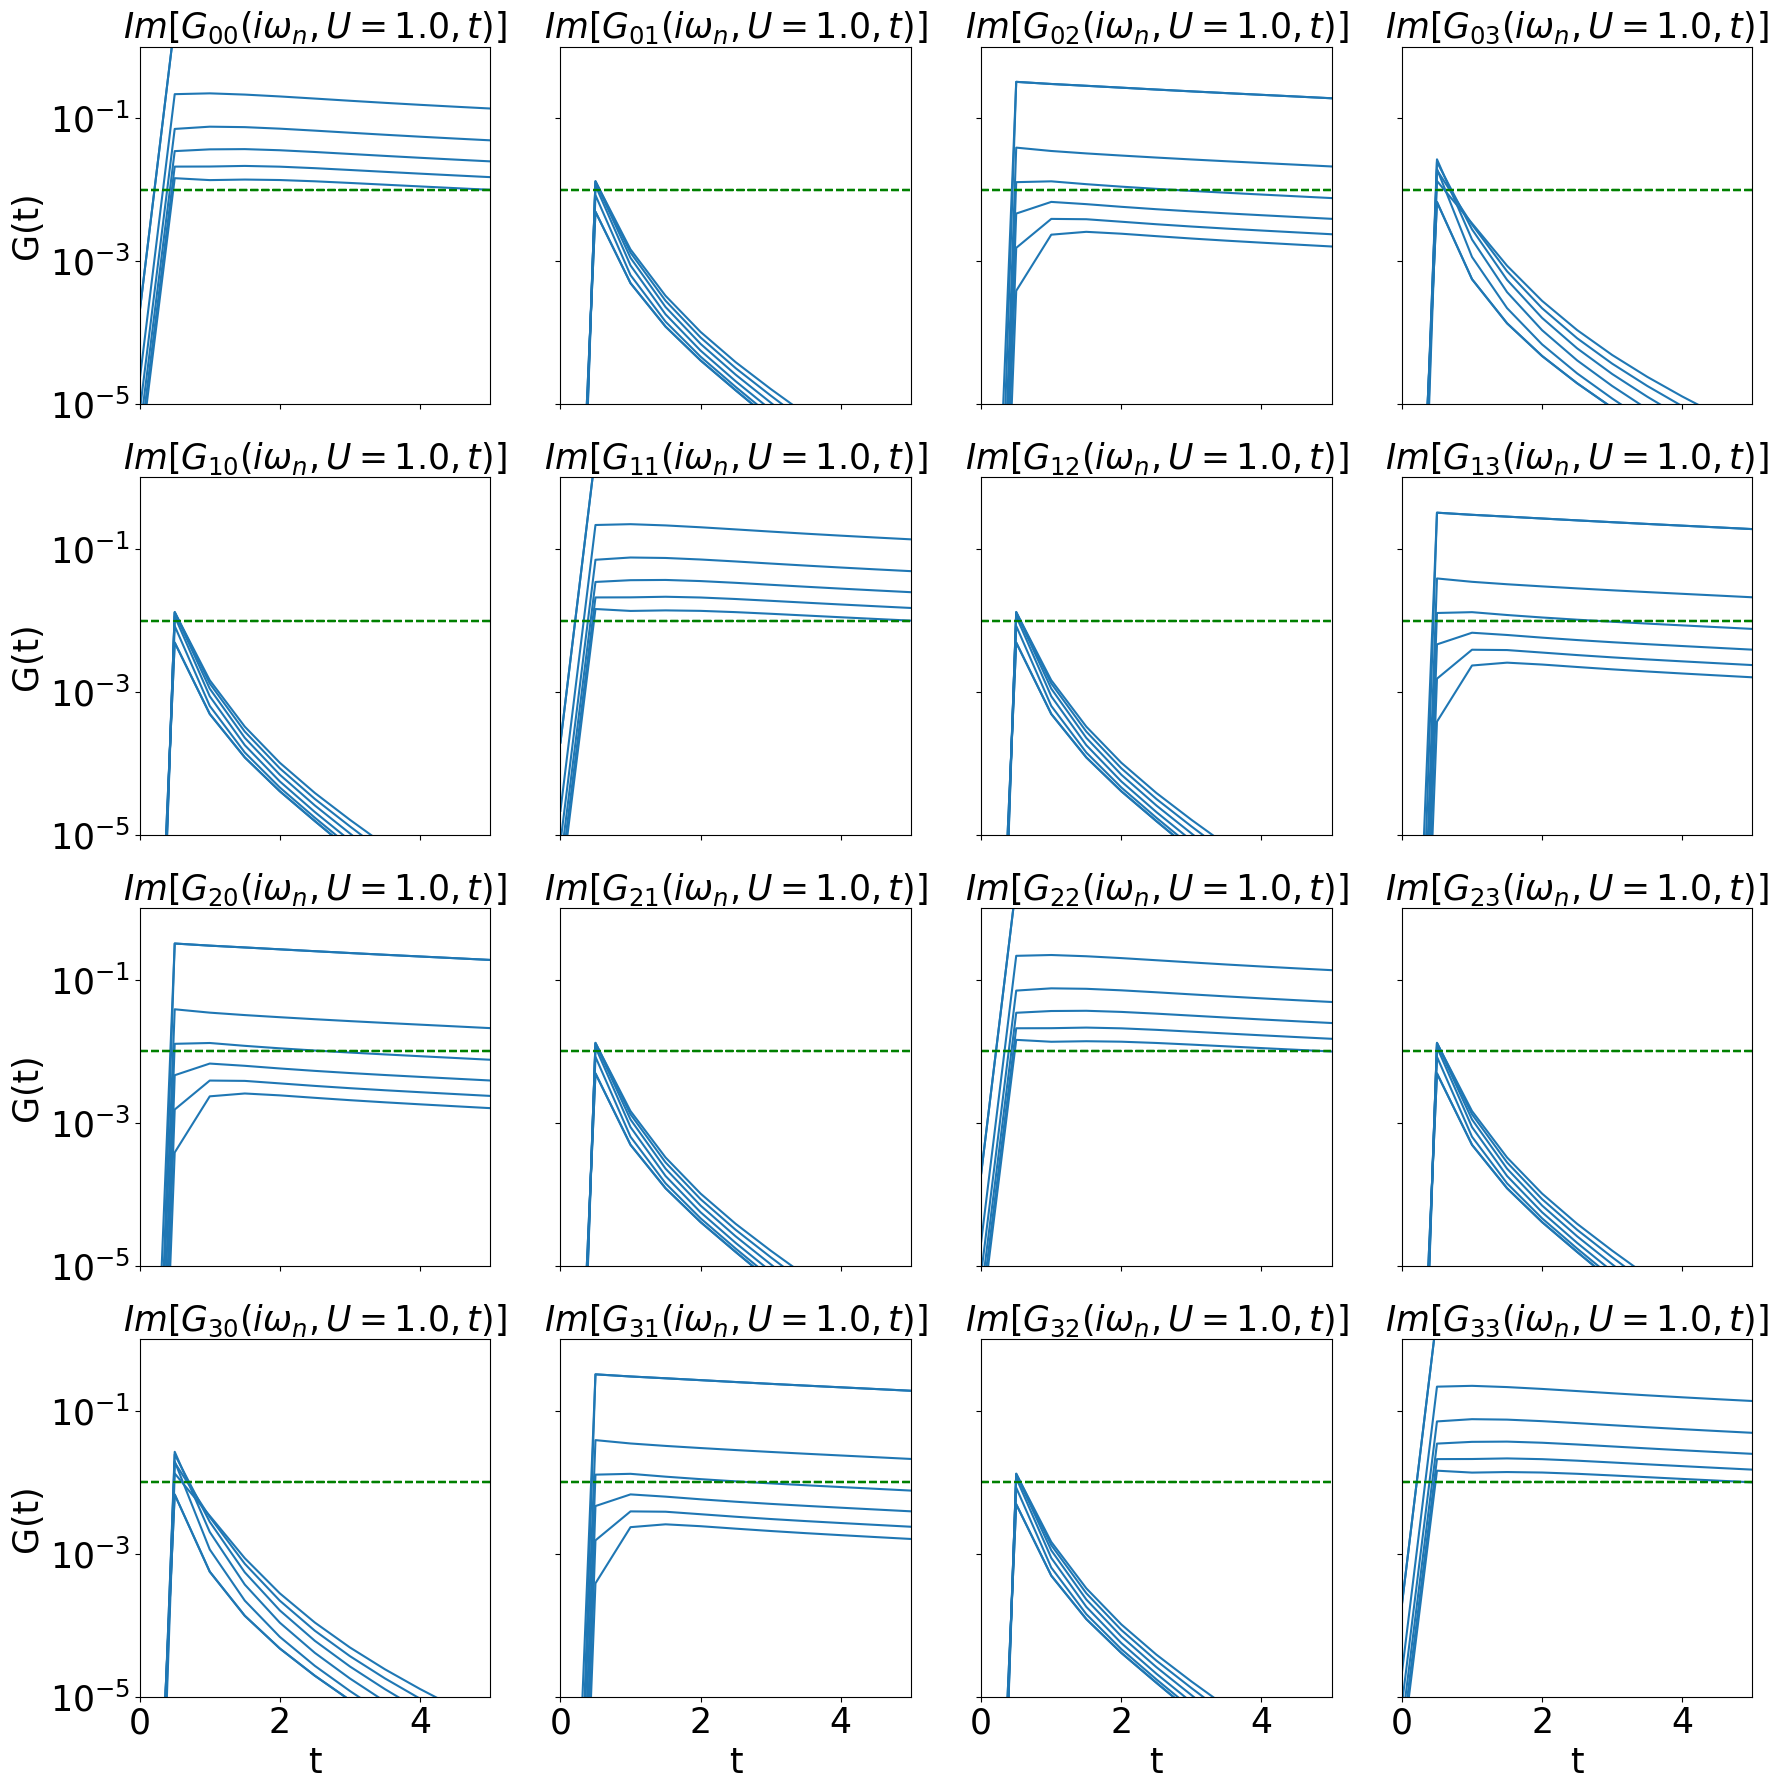

In [27]:
Ns_plot = 4
Ns_p = 0
# wn_id = [Nw, Nw-5, Nw-10, Nw-15, Nw-20]
# wn_id = [Nw]
wn_id = [Nw, Nw-1, Nw-2, Nw-3, Nw-4, Nw-5, Nw-6]
fig, axes = plt.subplots(Ns_plot, Ns_plot, figsize=(18, 18),sharex=True, sharey=True)

for i in range(Ns_plot):
    for j in range(Ns_plot):
        ax = axes[i, j]
        for k in wn_id:
            # ax.plot(t_values_wce, Gij_iwn_hf[:, k, i ,j+Ns_p ].real, 'C0')
            ax.plot(t_values_sce, Gij_iwn_sce[:, k, i,j+Ns_p ].real, 'C1--')
            ax.plot(t_values_wce, Gij_iwn_wce[:, k, i,j+Ns_p ].real, 'C2--')

        # ax.plot(t_values_wce, Gij_iwn_hf[:, k, i ,j+Ns_p ].real, 'C0', label ='hf')
        ax.plot(t_values_sce, Gij_iwn_sce[:, k, i ,j+Ns_p ].real, 'C1--', label ='sce')
        ax.plot(t_values_wce, Gij_iwn_wce[:, k, i ,j+Ns_p ].real, 'C2--', label ='wce')
        ax.set_title(r'$Re[G_{%d%d}(i\omega_n,U=%.1f, t)]$'%(i, j+Ns_p,1.0), fontsize=25)
        ax.tick_params(labelsize=25)
        ax.legend()
        if i == Ns_plot - 1:
            ax.set_xlabel("t", fontsize=25)
            ax.set_xlim([0,5])
            ax.set_ylim([-2,2])
        if j == 0:
            ax.set_ylabel("G(t)", fontsize=25)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(Ns_plot, Ns_plot, figsize=(18, 18),sharex=True, sharey=True)
for i in range(Ns_plot):
    for j in range(Ns_plot):
        ax = axes[i, j]
        for k in wn_id:
            ax.semilogy(t_values_wce, np.abs(Gij_iwn_hf[:, k, i ,j+Ns_p ].real-Gij_iwn_wce[:, k, i ,j+Ns_p ].real), 'C0')
            ax.semilogy(t_values_wce, 1e-2+0*t_values_wce, 'g--')
        ax.set_title(r'$Im[G_{%d%d}(i\omega_n,U=%.1f, t)]$'%(i,j,1.0), fontsize=25)
        ax.tick_params(labelsize=25)

        if i == Ns_plot - 1:
            ax.set_xlabel("t", fontsize=25)
            ax.set_xlim([0,5])
            ax.set_ylim([1e-5,1])
        if j == 0:
            ax.set_ylabel("G(t)", fontsize=25)

plt.tight_layout()
plt.show()


Test wns are [-0.11780972 -0.19634954 -0.27488936 -0.35342917 -0.43196899]


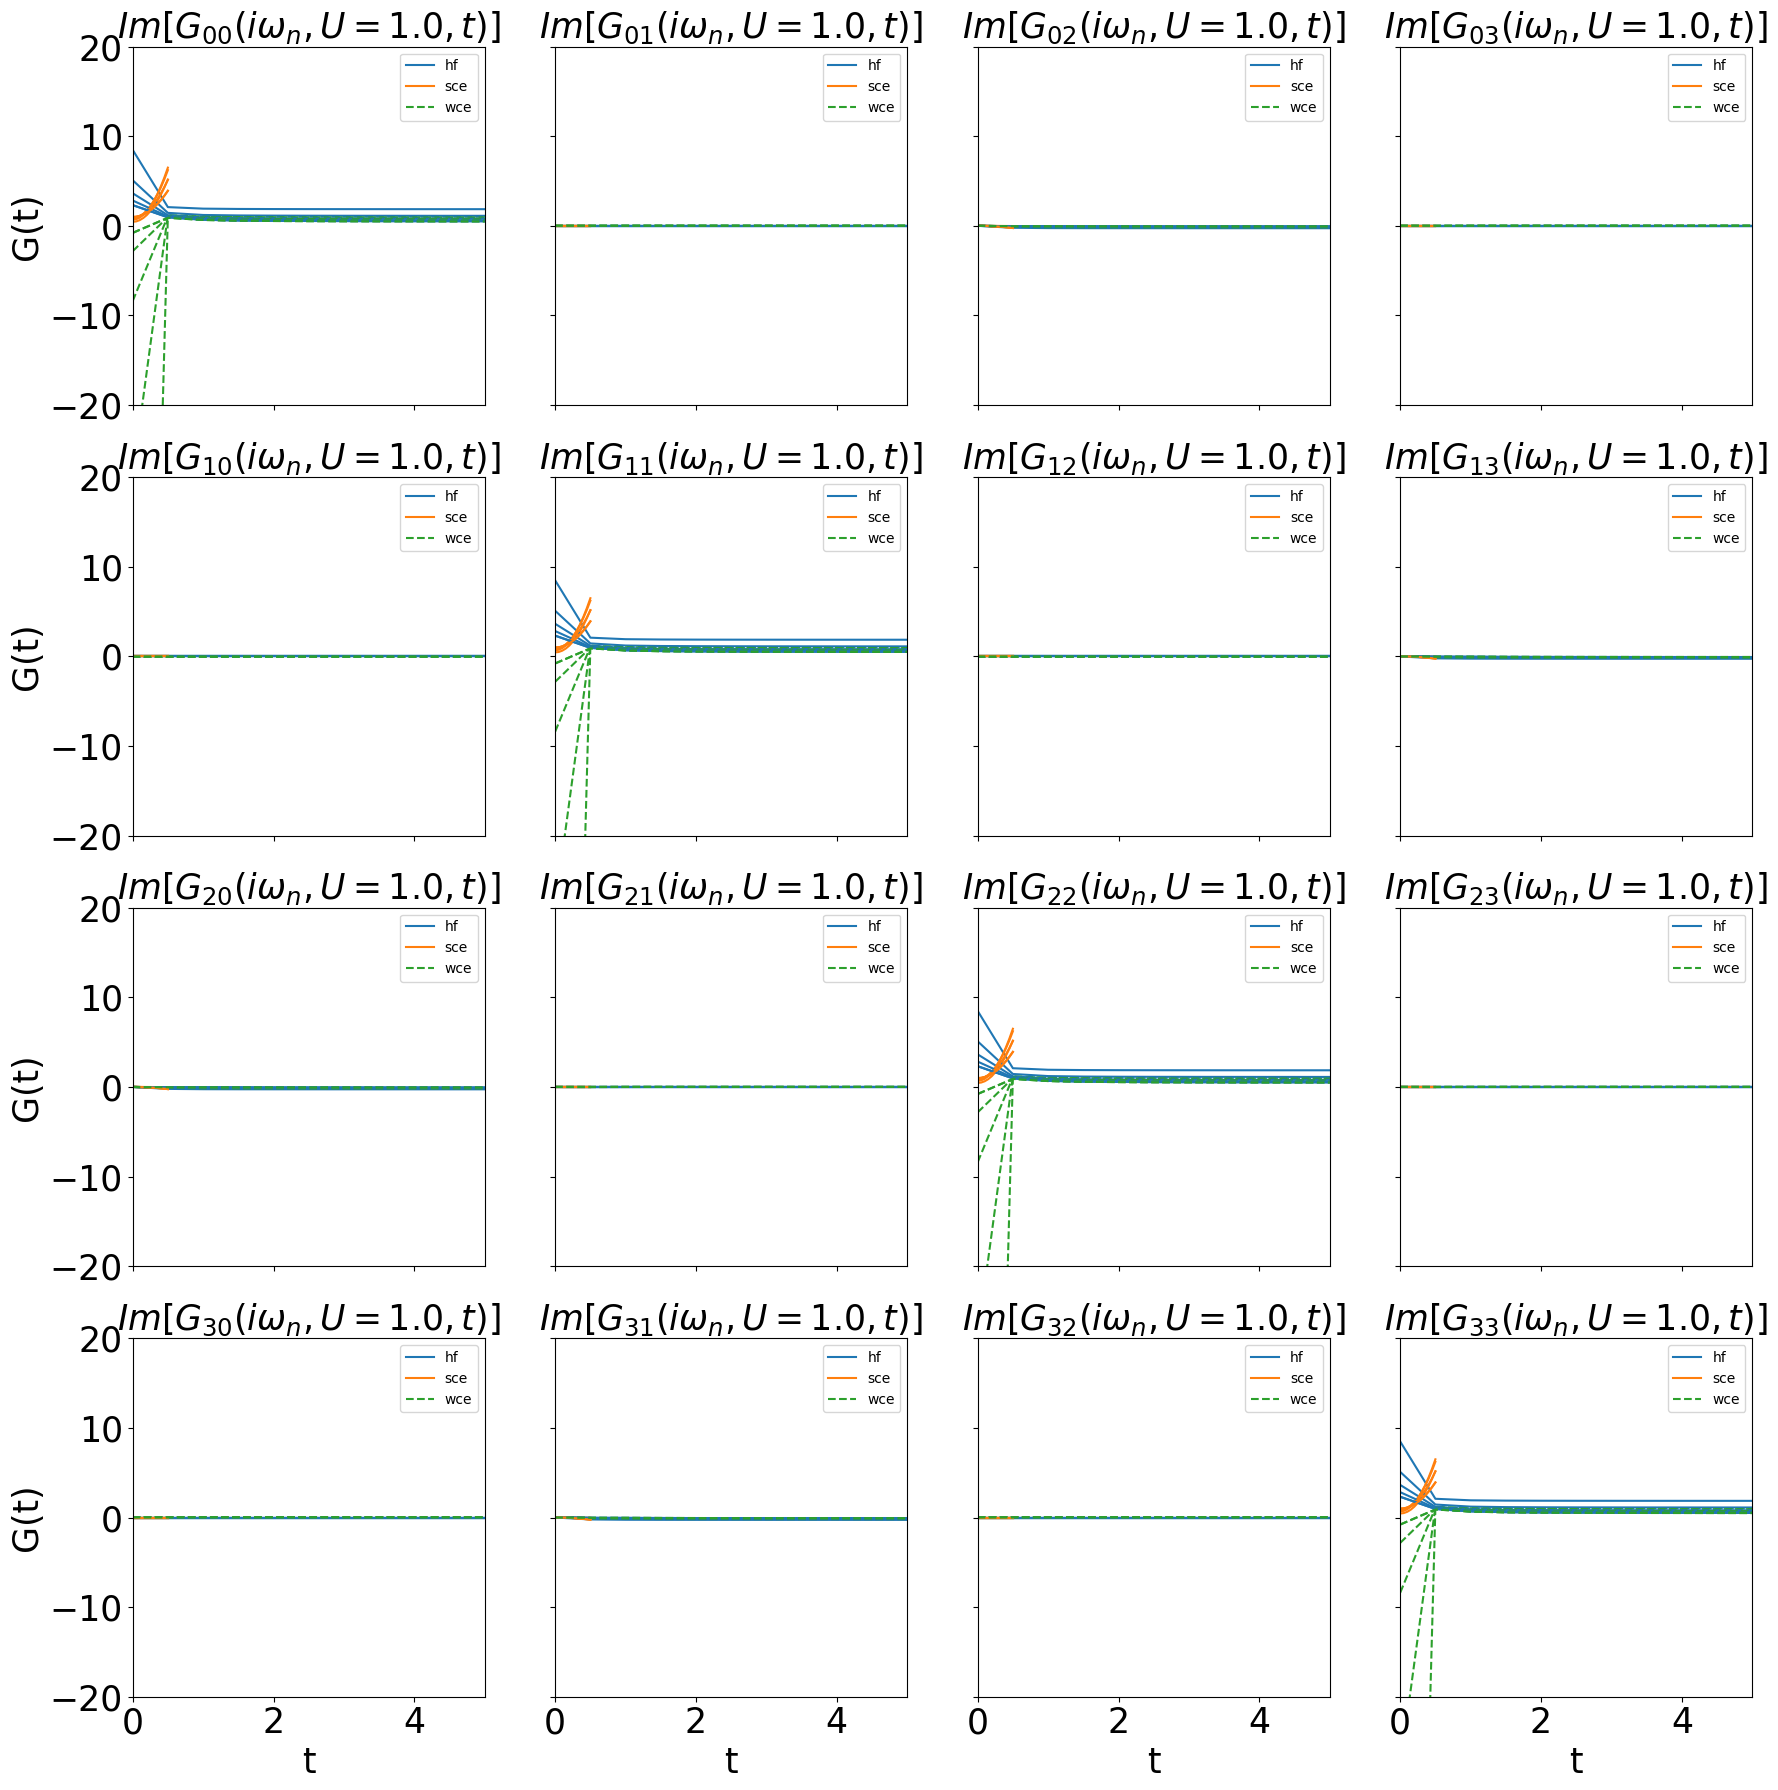

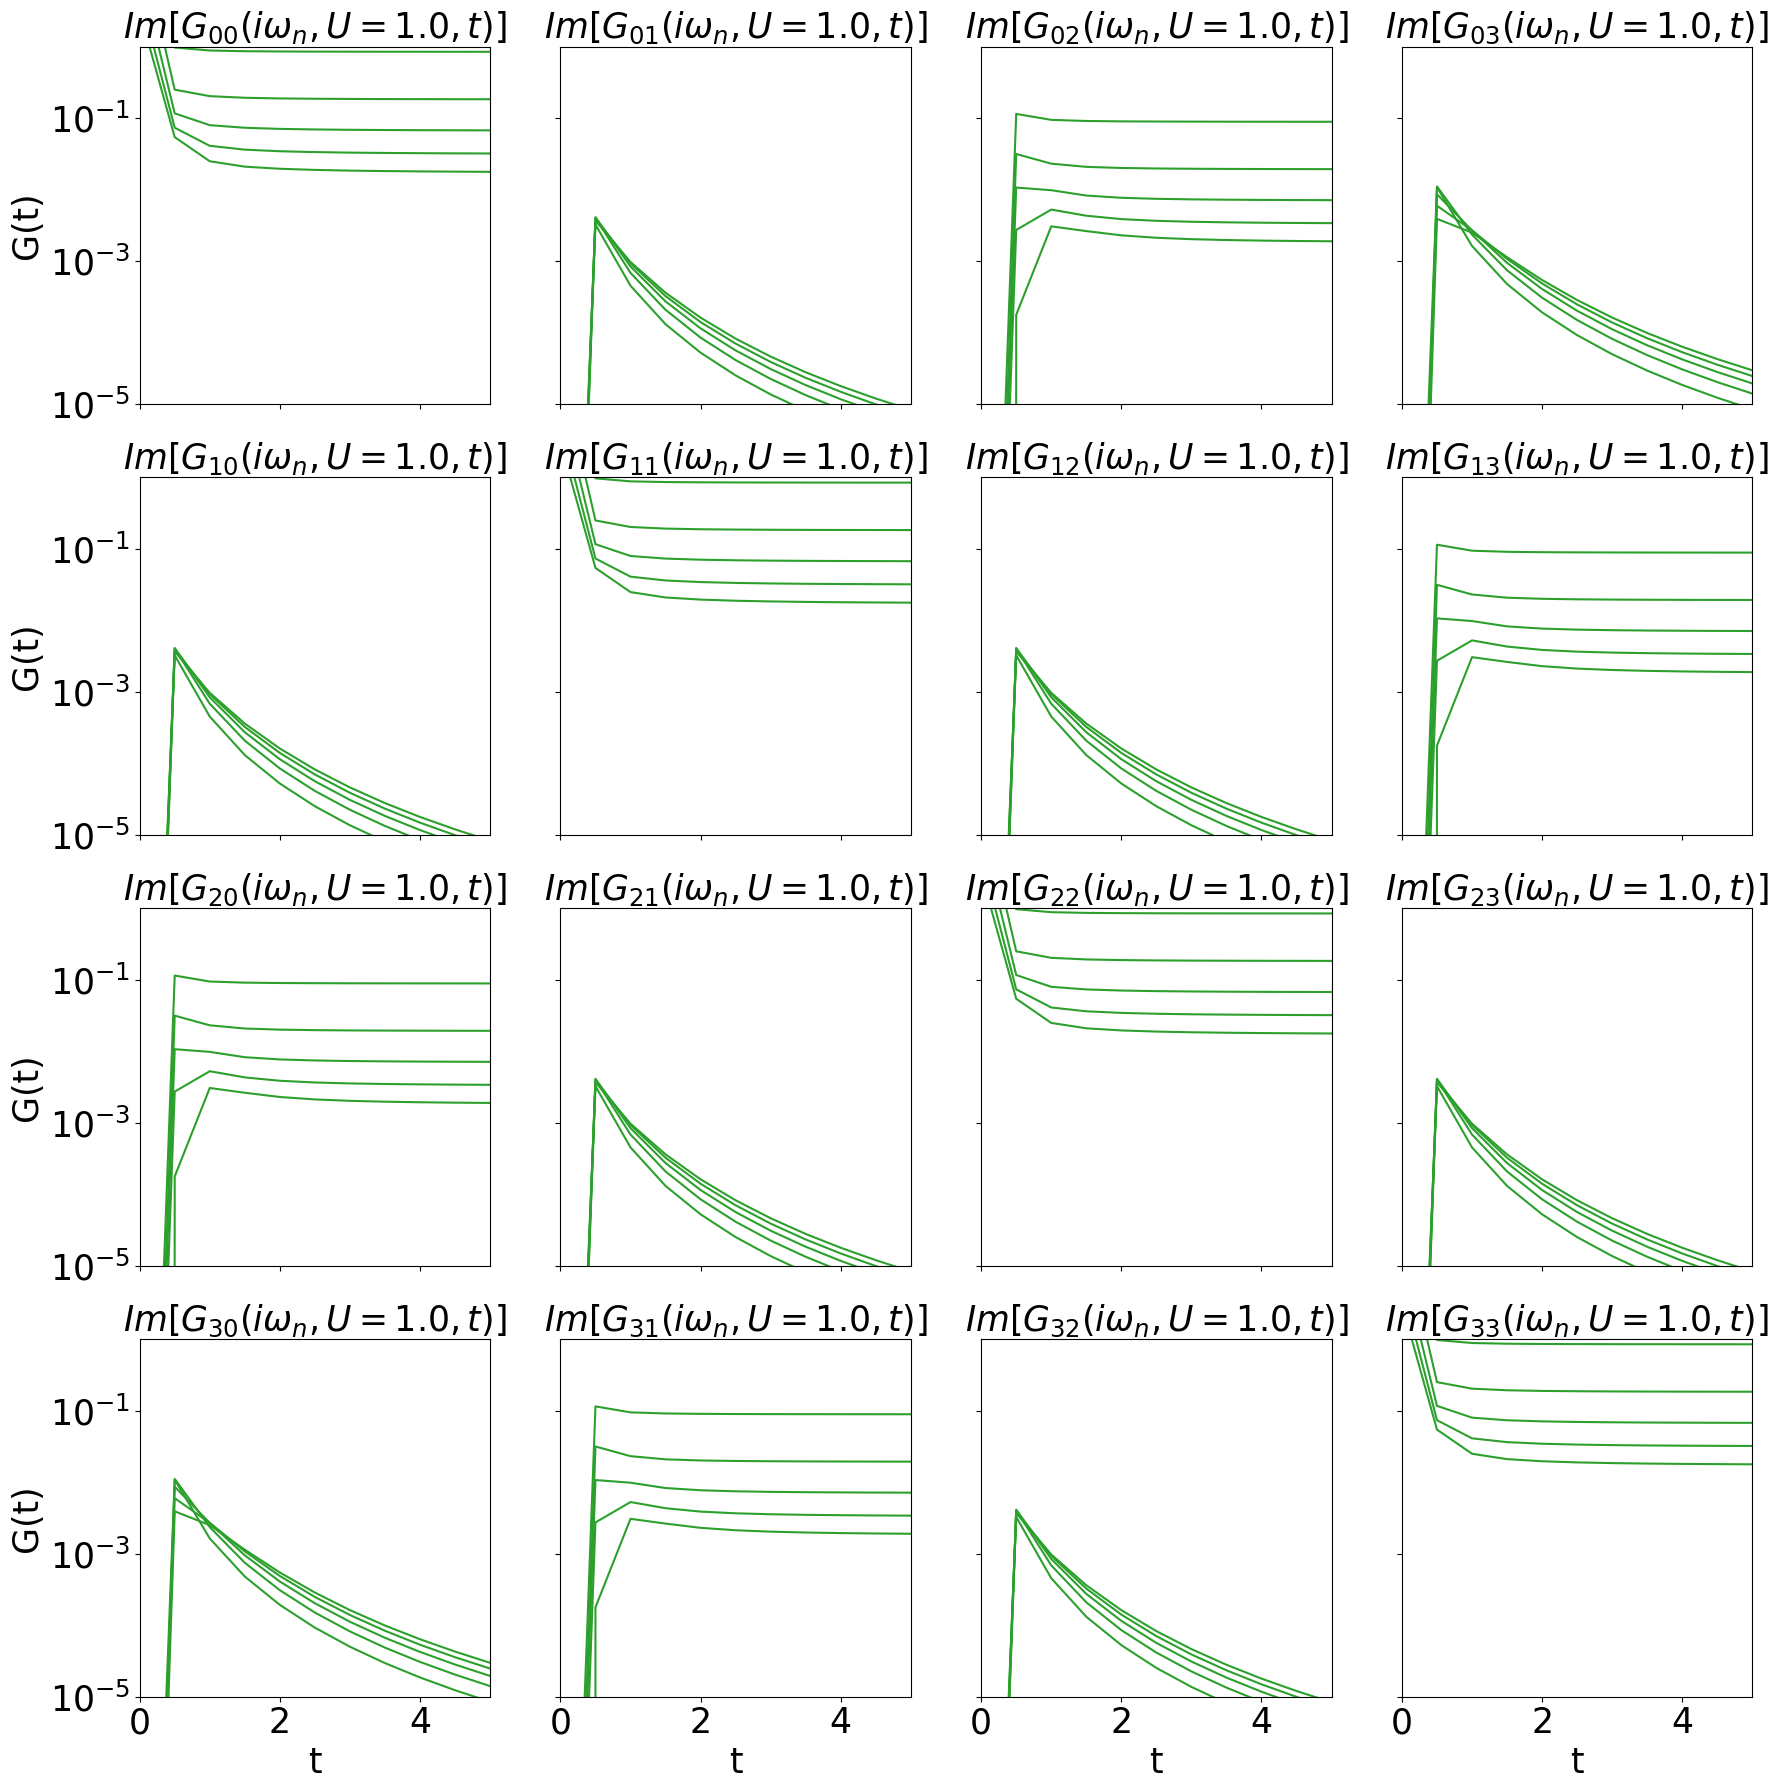

In [25]:
wn_id = [Nw-2, Nw-3, Nw-4, Nw-5, Nw-6]
print("Test wns are", wn[wn_id])
fig, axes = plt.subplots(Ns_plot, Ns_plot, figsize=(18, 18),sharex=True, sharey=True)

for i in range(Ns_plot):
    for j in range(Ns_plot):
        ax = axes[i, j]
        for k in wn_id:
            ax.plot(t_values_wce, Gij_iwn_hf[:, k, i ,j+Ns_p ].imag, 'C0')
            ax.plot(t_values_sce, Gij_iwn_sce[:, k, i ,j+Ns_p ].imag, 'C1')
            ax.plot(t_values_wce, Gij_iwn_wce[:, k, i ,j+Ns_p ].imag, 'C2--')
            
        ax.plot(t_values_wce, Gij_iwn_hf[:, k, i ,j+Ns_p ].imag, 'C0', label ='hf')
        ax.plot(t_values_sce, Gij_iwn_sce[:, k, i ,j+Ns_p ].imag, 'C1', label ='sce')
        ax.plot(t_values_wce, Gij_iwn_wce[:, k, i ,j+Ns_p ].imag, 'C2--', label ='wce')
        ax.set_title(r'$Im[G_{%d%d}(i\omega_n,U=%.1f, t)]$'%(i,j+Ns_p,1.0), fontsize=25)
        ax.tick_params(labelsize=25)
        ax.legend()
        if i == Ns_plot - 1:
            ax.set_xlabel("t", fontsize=25)
            ax.set_xlim([0,5])
            ax.set_ylim([-20,20])
        if j == 0:
            ax.set_ylabel("G(t)", fontsize=25)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(Ns_plot, Ns_plot, figsize=(18, 18),sharex=True, sharey=True)
for i in range(Ns_plot):
    for j in range(Ns_plot):
        ax = axes[i, j]
        for k in wn_id:
            ax.semilogy(t_values_wce, np.abs(Gij_iwn_hf[:, k, i ,j+Ns_p ].imag-Gij_iwn_wce[:, k, i ,j+Ns_p ].imag), 'C2')
        ax.set_title(r'$Im[G_{%d%d}(i\omega_n,U=%.1f, t)]$'%(i,j+Ns_p,1.0), fontsize=25)
        ax.tick_params(labelsize=25)

        if i == Ns_plot - 1:
            ax.set_xlabel("t", fontsize=25)
            ax.set_xlim([0,5])
            ax.set_ylim([1e-5,1])
        if j == 0:
            ax.set_ylabel("G(t)", fontsize=25)

plt.tight_layout()
plt.show()


In [16]:
# Gij_tau_wce = np.zeros((t_values_wce.size, Ntau, Ns, Ns))
# Gij_tau_hf = np.zeros((t_values_wce.size, Ntau, Ns, Ns))
# for t in range(t_values_wce.size):
#     Gij_tau_wce[t] = np.real(wce.Gij_iwn_to_Gij_tau(Gij_iwn_wce[t], wn, np.linspace(0,beta,Ntau), beta))
#     Gij_tau_hf[t] = np.real(wce.Gij_iwn_to_Gij_tau(Gij_iwn_hf[t], wn, np.linspace(0,beta,Ntau), beta))

In [ ]:
# fig, axes = plt.subplots(Ns, Ns, figsize=(18, 18),sharex=True, sharey=True)
# t_id = [-1]
# for i in range(Ns):
#     for j in range(Ns):
#         ax = axes[i, j]
#         for k in t_id:
#             ax.plot(np.linspace(0,beta,Ntau), -Gij_tau_ED[k, :, i ,j ], 'C0')
#             ax.plot(np.linspace(0,beta,Ntau), -Gij_tau_hf[k, :, i ,j ], 'C1--')
#             ax.plot(np.linspace(0,beta,Ntau), -Gij_tau_wce[k, :, i ,j ], 'C2--')  
#         ax.set_title(r'$-G_{%d%d}(\tau, t=%.1f)]$'%(i,j, t_values_ED[t_id]), fontsize=25)
#         ax.tick_params(labelsize=25)

#         if i == Ns - 1:
#             ax.set_xlabel(r"$\tau$", fontsize=25)
#             ax.set_xlim([0,beta])
#             ax.set_ylim([-1,1])
#         if j == 0:
#             ax.set_ylabel(r"$G(\tau)$", fontsize=25)

# plt.tight_layout()
# plt.show()


In [ ]:
# Gij_iwn_test = G0_bare(Ns, wn, 0.2)
# Gij_tau_test = np.real(wce.Gij_iwn_to_Gij_tau(Gij_iwn_test, wn, np.linspace(0,beta,Ntau), beta))
# fig, axes = plt.subplots(Ns, Ns, figsize=(18, 18),sharex=True, sharey=True)
# t_id = [40]
# for i in range(Ns):
#     for j in range(Ns):
#         ax = axes[i, j]
#         ax.plot(np.linspace(0,beta,Ntau), -Gij_tau_test[:, i ,j ], 'C0')
#         ax.set_title(r'$-G_{%d%d}(\tau, U=%.1f)]$'%(i,j,0.2), fontsize=25)
#         ax.tick_params(labelsize=25)

#         if i == Ns - 1:
#             ax.set_xlabel(r"$\tau$", fontsize=25)
#             ax.set_xlim([0,beta])
#             ax.set_ylim([-1,1])
#         if j == 0:
#             ax.set_ylabel(r"$G(\tau)$", fontsize=25)

# plt.tight_layout()
# plt.show()